# Example 02 - Crypto portfolio from the `major_crypto` preset

Loads one year of daily prices for the five assets of the `major_crypto` preset
(BTC, ETH, BNB, SOL, ADA) through `quick_portfolio_load`, builds a five-variable QUBO
that selects two of them, and compares QAOA with the Rust simulated-annealing solver
against the brute-force optimum. A risk-return scatter highlights the QAOA selection.

**Network:** the first run of the day downloads from Yahoo Finance (free, no API key);
the loader then caches per-symbol CSVs under `data/cache/` relative to the working
directory. The outputs below reflect the day this notebook was last executed.

This notebook mirrors `02_crypto_portfolio.py`, which is the tested source of truth.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import qaoa_portfolio_core as core
from qaoa_portfolio import (
    QAOAConfig,
    plot_portfolio_composition,
    plot_risk_return_scatter,
    quick_portfolio_load,
    solve_qubo_qaoa,
)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

PRESET = "major_crypto"
DAYS_BACK = 365
RISK_FACTOR = 0.5
TARGET_ASSETS = 2
SEED = 11

In [2]:
from IPython.display import Image, display

def save_and_show(figures, prefix):
    """Save each figure to output/ (like the script) and display the PNG."""
    paths = []
    for name, figure in figures.items():
        path = OUTPUT_DIR / f"{prefix}_{name}.png"
        figure.savefig(path, bbox_inches="tight", dpi=100)
        paths.append(path)
        display(Image(filename=str(path)))
    return paths

## 1. Data

`quick_portfolio_load` is a coroutine. The script drives it with `asyncio.run()`;
inside a notebook the event loop is already running, so we `await` it directly.
It returns `(price_data, returns_data)`; `price_data` has `(symbol, price_type)`
columns.

In [3]:
price_data, _ = await quick_portfolio_load(preset=PRESET, days_back=DAYS_BACK)

symbols = list(price_data.columns.get_level_values(0).unique())
closes = pd.DataFrame({s: price_data[(s, "close")] for s in symbols}).dropna()
labels = list(closes.columns)
# A symbol can fail to download and be dropped; never ask for more holdings
# than there are assets.
target_assets = min(TARGET_ASSETS, len(labels))
print(
    f"Loaded {len(labels)} assets x {len(closes)} days "
    f"({closes.index[0].date()} -> {closes.index[-1].date()})"
)

Loaded 5 assets x 365 days (2025-10-09 -> 2026-10-08)


## 2. QUBO

In [4]:
prices = closes.to_numpy(dtype=np.float64)
qubo = core.build_qubo(prices, labels, RISK_FACTOR, target_assets)

## 3. Solve three ways

Brute force (2^5 = 32 candidates) is the reference; simulated annealing is the fast
classical heuristic; QAOA is p = 1 with COBYLA.

In [5]:
exact = core.solve_brute_force(qubo)
annealed = core.solve_simulated_annealing(qubo, seed=SEED)
optimum_bitstring = "".join("1" if bit else "0" for bit in exact.solution)
result = solve_qubo_qaoa(
    qubo,
    labels=labels,
    config=QAOAConfig(
        layers=1,
        optimizer="cobyla",
        max_iterations=60,
        num_restarts=2,
        seed=SEED,
        target_assets=target_assets,
    ),
    reference_bitstrings=[optimum_bitstring],
)

solutions = {
    "brute_force": (list(exact.selected_assets), exact.objective_value),
    "simulated_annealing": (list(annealed.selected_assets), annealed.objective_value),
    "qaoa": (list(result.selected_assets), result.objective_value),
}
for name, (assets, objective) in solutions.items():
    print(f"{name:<20} {', '.join(assets):<20} objective {objective:.6f}")

brute_force          BTC-USD, BNB-USD     objective 0.542992
simulated_annealing  BTC-USD, BNB-USD     objective 0.542992
qaoa                 BTC-USD, BNB-USD     objective 0.542992


As in example 01: with 5 assets every bitstring is kept for decoding, so the decoded
QAOA answer is the optimum by construction. P(optimum) and P(feasible) measure the
circuit itself - a single p = 1 layer is shallow, and on real data it can concentrate
little (or even less than uniform) probability on the optimum.

In [6]:
p_opt = result.metadata["reference_probabilities"][optimum_bitstring]
print(
    f"QAOA P(optimum) {p_opt:.3f} (uniform {1 / 2 ** len(labels):.3f}), "
    f"P(feasible) {result.metadata['feasible_probability']:.3f}"
)

QAOA P(optimum) 0.069 (uniform 0.031), P(feasible) 0.650


## 4. Figures

Risk-return uses daily simple returns of the same close prices; the QAOA selection is
highlighted.

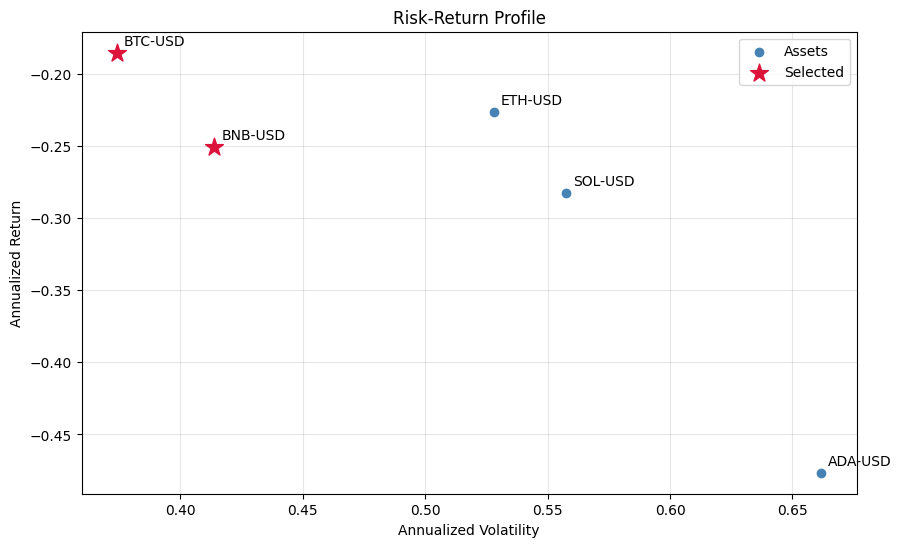

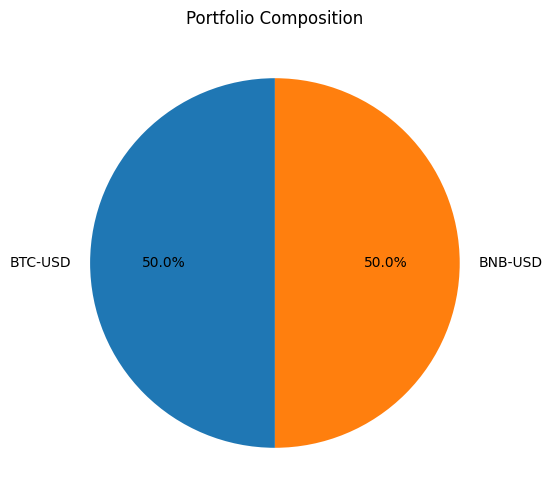

In [7]:
returns = closes.pct_change().dropna()
paths = save_and_show(
    {
        "risk_return": plot_risk_return_scatter(
            returns, highlighted_assets=result.selected_assets
        ),
        "composition": plot_portfolio_composition(result.selected_assets),
    },
    prefix="02",
)